<a href="https://colab.research.google.com/github/Shashank-sketchAl/ML-90-Day-Challenge-/blob/main/SalaryPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving adult.csv to adult.csv


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('adult.csv')

In [4]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.shape

(32561, 15)

In [6]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [9]:
for col in df.columns:
    print(col, (df[col] == '?').sum())

age 0
workclass 1836
fnlwgt 0
education 0
education.num 0
marital.status 0
occupation 1843
relationship 0
race 0
sex 0
capital.gain 0
capital.loss 0
hours.per.week 0
native.country 583
income 0


In [10]:
df = df.replace('?', pd.NA)

In [11]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [12]:
df = df.dropna()

In [13]:
df.shape

(30162, 15)

In [14]:
df.duplicated().sum()

np.int64(23)

In [15]:
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['income'].value_counts()

,count
income,
<=50K,22633
>50K,7506


In [18]:
df['income'].value_counts(normalize=True) * 100

,proportion
income,
<=50K,75.095391
>50K,24.904609


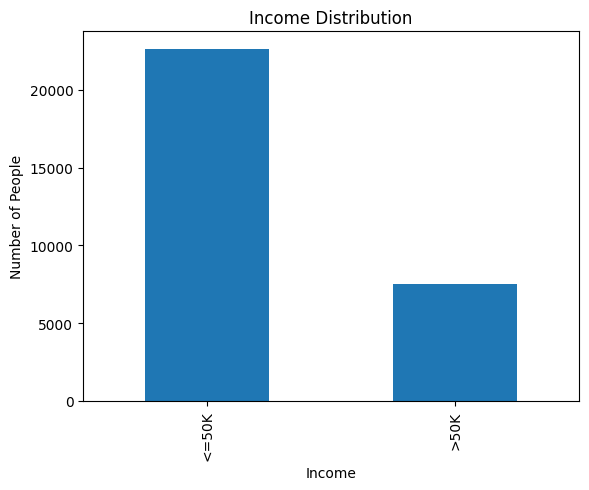

In [19]:
import matplotlib.pyplot as plt

df['income'].value_counts().plot(kind='bar')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Number of People')
plt.show()

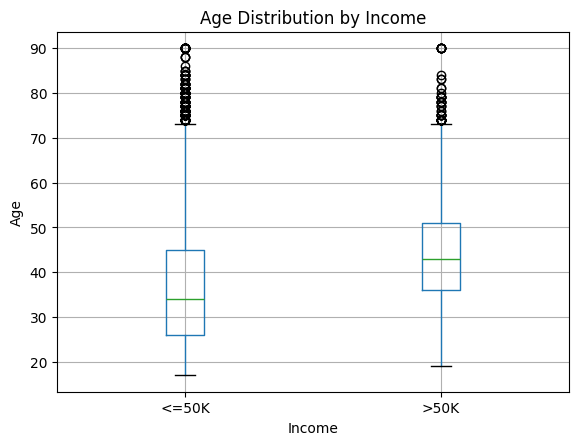

In [20]:
df.boxplot(column='age', by='income')
plt.title('Age Distribution by Income')
plt.suptitle('')
plt.xlabel('Income')
plt.ylabel('Age')
plt.show()

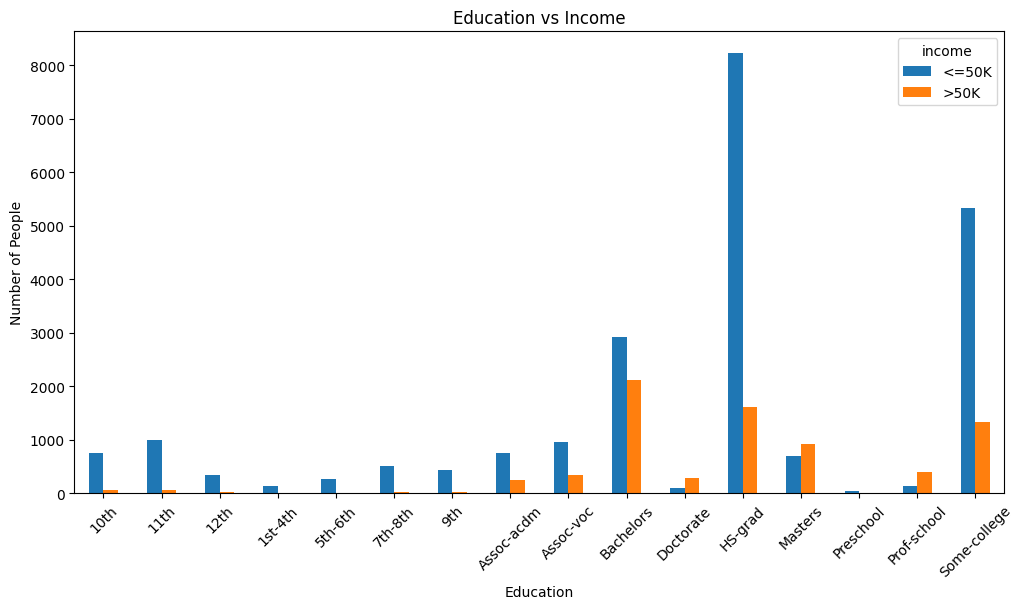

In [21]:
pd.crosstab(df['education'], df['income']).plot(kind='bar', figsize=(12,6))

plt.title('Education vs Income')
plt.xlabel('Education')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.show()

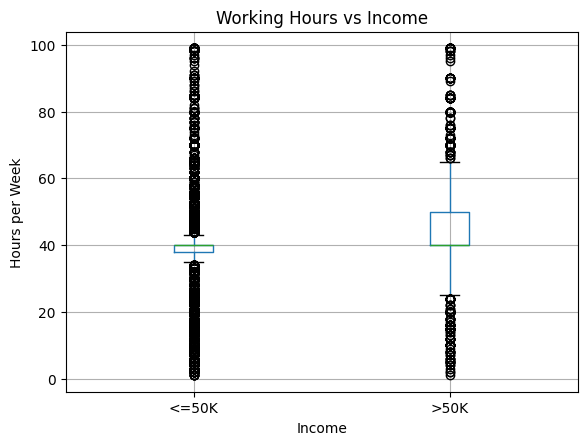

In [23]:
df.boxplot(column='hours.per.week', by='income')
plt.title('Working Hours vs Income')
plt.suptitle('')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

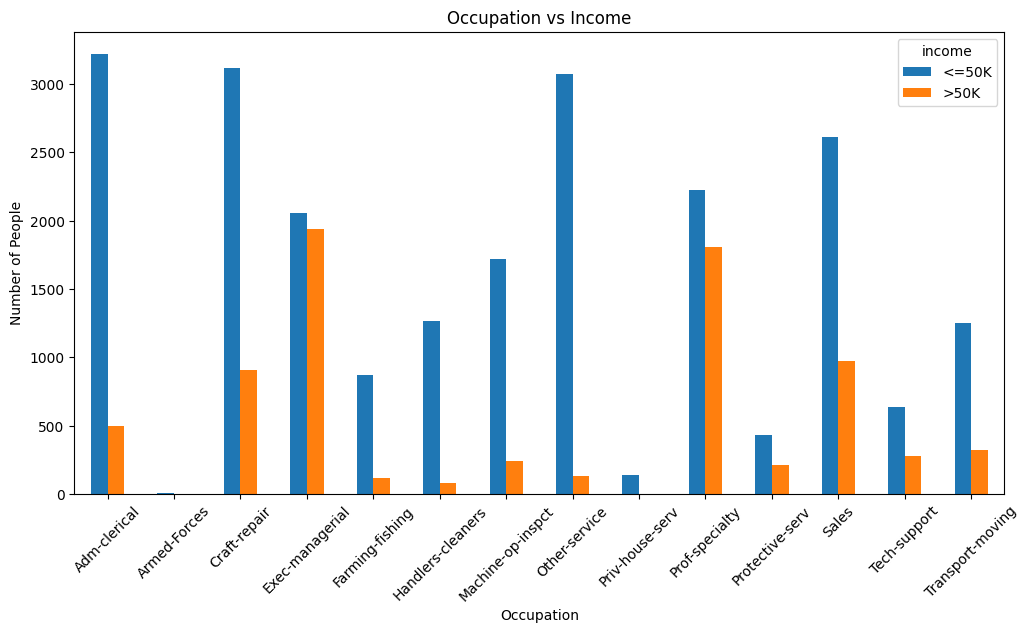

In [24]:
pd.crosstab(df['occupation'], df['income']).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Occupation vs Income')
plt.xlabel('Occupation')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.show()

### EDA Observations

1. Income distribution shows the proportion of people earning above and below $50K.
2. Age appears to have a relationship with income level.
3. Education level shows differences in income distribution.
4. Working hours may influence the probability of earning more than $50K.
5. Income distribution varies across different occupations.

###Data Preprocessing

In [25]:
X = df.drop('income', axis=1)
y = df['income']

In [26]:
print(X.shape)
print(y.shape)

(30139, 14)
(30139,)


In [27]:
y = y.map({
    '<=50K': 0,
    '>50K': 1
})

In [28]:
y.value_counts()

,count
income,
0,22633
1,7506


numerical and categorical columns

In [29]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

Categorical columns:
Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')


In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

##Split the data

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24111, 14)
Testing data: (6028, 14)


In [34]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [35]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(24111, 103)
(6028, 103)


##Import Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
model_lr = LogisticRegression(max_iter=1000)

In [38]:
model_lr.fit(X_train_processed, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [39]:
y_pred_lr = model_lr.predict(X_test_processed)

In [40]:
print(y_pred_lr[:20])

[0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1]


In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [42]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Accuracy : 0.8475447909754479
Precision: 0.7487179487179487
Recall   : 0.5836109260493004
F1 Score : 0.6559341070760015


##Generate a classification report

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4527
           1       0.75      0.58      0.66      1501

    accuracy                           0.85      6028
   macro avg       0.81      0.76      0.78      6028
weighted avg       0.84      0.85      0.84      6028



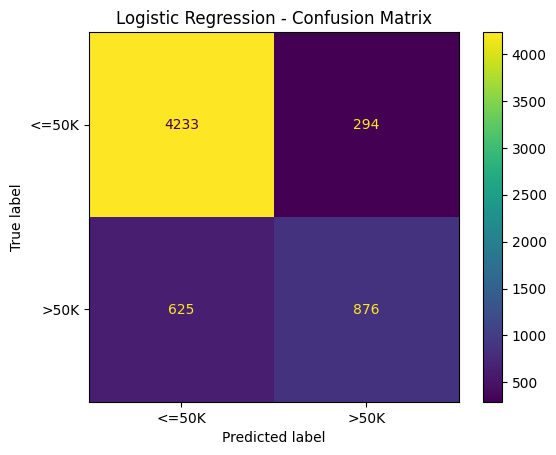

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['<=50K', '>50K']
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Logistic Regression Observations

- Logistic Regression was used as the baseline classification model.
- The model predicts whether an individual's income is <=50K or >50K.
- Accuracy, precision, recall, and F1-score were used for evaluation.
- The confusion matrix helps identify correct and incorrect predictions for both income classes.
- The results provide a baseline for comparison with more complex models.

##Import Decision Tree

In [45]:
from sklearn.tree import DecisionTreeClassifier

In [46]:
model_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

In [47]:
model_dt.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [48]:
y_pred_dt = model_dt.predict(X_test_processed)

In [49]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Accuracy : 0.8558394160583942
Precision: 0.7263610315186246
Recall   : 0.6755496335776149
F1 Score : 0.7000345184673801


In [50]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91      4527
           1       0.73      0.68      0.70      1501

    accuracy                           0.86      6028
   macro avg       0.81      0.80      0.80      6028
weighted avg       0.85      0.86      0.85      6028



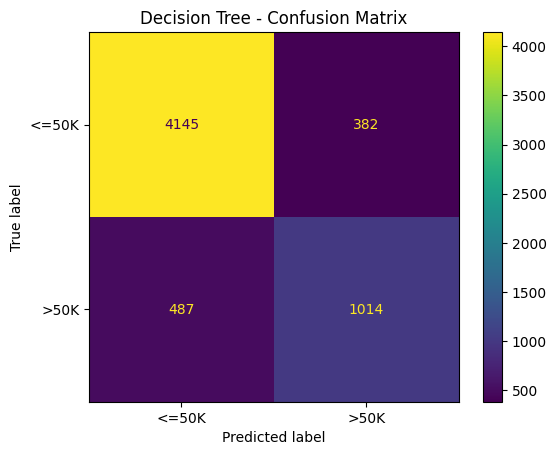

In [51]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=['<=50K', '>50K']
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

### Decision Tree Observations

- Decision Tree was trained to classify individuals into <=50K and >50K income groups.
- The tree can capture non-linear relationships between features.
- A maximum depth of 10 was used to reduce the possibility of overfitting.
- The model was evaluated using accuracy, precision, recall, F1-score and a confusion matrix.
- Its performance will be compared with Logistic Regression and Random Forest.

##Import Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [54]:
model_rf.fit(X_train_processed, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [55]:
y_pred_rf = model_rf.predict(X_test_processed)

In [56]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.8515262110152622
Precision: 0.7267964071856288
Recall   : 0.6469020652898068
F1 Score : 0.684525907648925


In [57]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4527
           1       0.73      0.65      0.68      1501

    accuracy                           0.85      6028
   macro avg       0.81      0.78      0.79      6028
weighted avg       0.85      0.85      0.85      6028



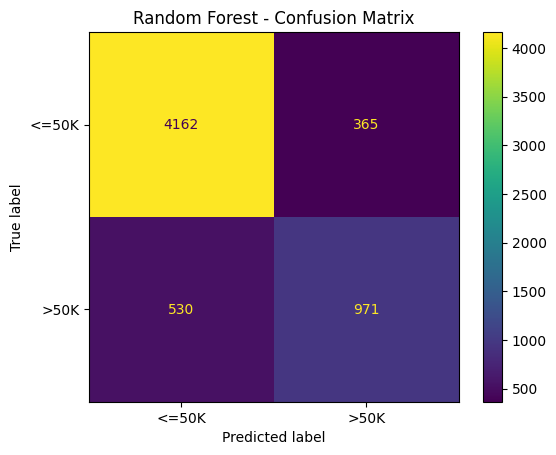

In [58]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['<=50K', '>50K']
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

###Compare All Three Models

In [59]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],
    'Precision': [
        precision_lr,
        precision_dt,
        precision_rf
    ],
    'Recall': [
        recall_lr,
        recall_dt,
        recall_rf
    ],
    'F1 Score': [
        f1_lr,
        f1_dt,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.847545,0.748718,0.583611,0.655934
1,Decision Tree,0.855839,0.726361,0.675550,0.700035
2,Random Forest,0.851526,0.726796,0.646902,0.684526


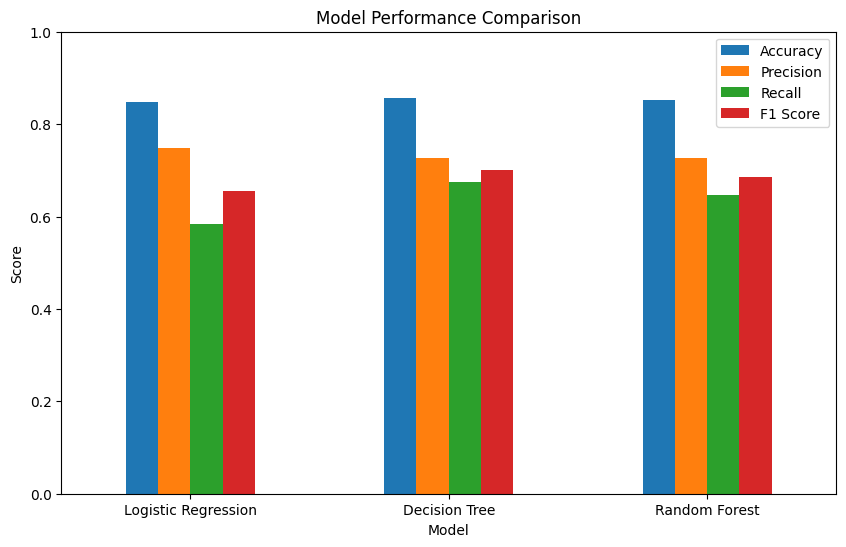

In [60]:
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

### Model Comparison

Three classification models were trained:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models were compared using accuracy, precision, recall and F1-score.

Random Forest combines multiple decision trees and can capture more complex relationships in the dataset. The final model selection should be based on the evaluation metrics rather than accuracy alone.

In [62]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.847545,0.748718,0.583611,0.655934
1,Decision Tree,0.855839,0.726361,0.675550,0.700035
2,Random Forest,0.851526,0.726796,0.646902,0.684526


In [63]:
feature_names = preprocessor.get_feature_names_out()

In [64]:
print("Number of features:", len(feature_names))

Number of features: 103


In [65]:
importance = model_rf.feature_importances_

In [66]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

In [67]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [68]:
feature_importance.head(15)

,Feature,Importance
1,num__fnlwgt,0.160373
0,num__age,0.145907
3,num__capital.gain,0.097584
5,num__hours.per.week,0.083184
31,cat__marital.status_Married-civ-spouse,0.066534
2,num__education.num,0.058755
50,cat__relationship_Husband,0.045953
4,num__capital.loss,0.028959
33,cat__marital.status_Never-married,0.020268
39,cat__occupation_Exec-managerial,0.018571


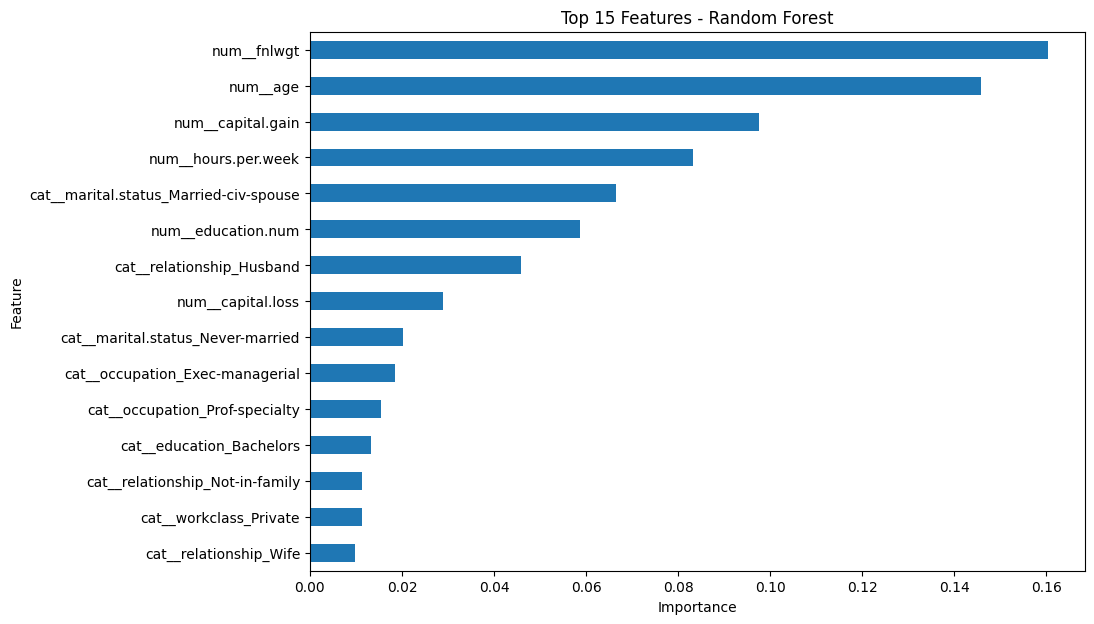

In [69]:
top_features = feature_importance.head(15)

top_features.plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(10, 7),
    legend=False
)

plt.title('Top 15 Features - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

### Feature Importance Observations

- Random Forest feature importance was used to identify the features that contributed most to prediction.
- The most important features were identified from the trained Random Forest model.
- Features such as age, education, working hours, capital gain/loss, and occupation may contribute significantly to income classification.
- Feature importance indicates predictive usefulness and does not necessarily imply a causal relationship.

In [70]:
best_model = results.loc[
    results['F1 Score'].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Decision Tree
Accuracy          0.855839
Precision         0.726361
Recall             0.67555
F1 Score          0.700035
Name: 1, dtype: object


In [71]:
best_accuracy_model = results.loc[
    results['Accuracy'].idxmax()
]

print("Best Accuracy Model:")
print(best_accuracy_model)

Best Accuracy Model:
Model        Decision Tree
Accuracy          0.855839
Precision         0.726361
Recall             0.67555
F1 Score          0.700035
Name: 1, dtype: object


###ROC-AUC for Logistic Regression

In [72]:
y_prob_lr = model_lr.predict_proba(X_test_processed)[:, 1]

In [73]:
y_prob_dt = model_dt.predict_proba(X_test_processed)[:, 1]

In [74]:
y_prob_rf = model_rf.predict_proba(X_test_processed)[:, 1]

In [75]:
from sklearn.metrics import roc_auc_score

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression AUC:", auc_lr)
print("Decision Tree AUC:", auc_dt)
print("Random Forest AUC:", auc_rf)

Logistic Regression AUC: 0.8863839687465553
Decision Tree AUC: 0.9030349695446391
Random Forest AUC: 0.9059996376762005


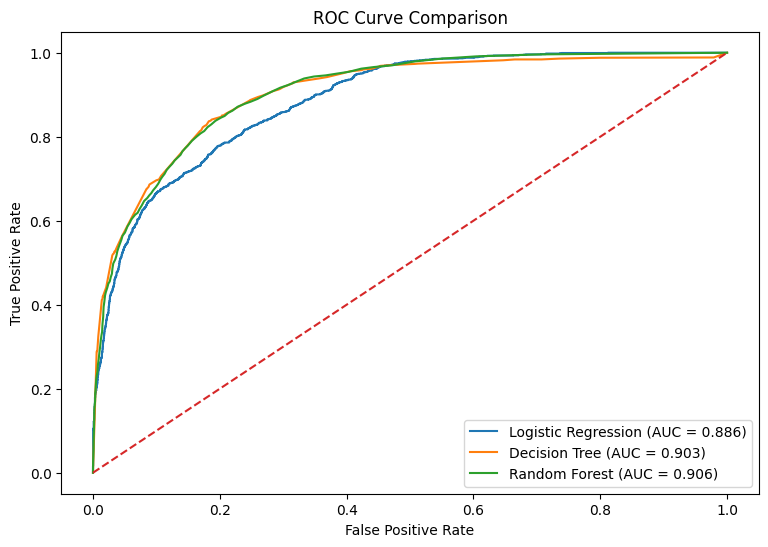

In [76]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(9, 6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [77]:
results['ROC-AUC'] = [
    auc_lr,
    auc_dt,
    auc_rf
]

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.847545,0.748718,0.583611,0.655934,0.886384
1,Decision Tree,0.855839,0.726361,0.675550,0.700035,0.903035
2,Random Forest,0.851526,0.726796,0.646902,0.684526,0.906000


### ROC-AUC Evaluation

ROC-AUC was used to evaluate the ability of the models to distinguish between the two income classes.

The ROC curve compares the True Positive Rate with the False Positive Rate at different classification thresholds.

AUC provides a threshold-independent measure of classification performance.

The ROC-AUC scores of Logistic Regression, Decision Tree, and Random Forest were compared to determine which model provided the strongest overall discrimination.

###Final Model Selection

In [78]:
best_model_name = results.loc[
    results['F1 Score'].idxmax(),
    'Model'
]

print("Best Model based on F1 Score:", best_model_name)

Best Model based on F1 Score: Decision Tree


In [79]:
results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,0.855839,0.726361,0.675550,0.700035,0.903035
2,Random Forest,0.851526,0.726796,0.646902,0.684526,0.906000
0,Logistic Regression,0.847545,0.748718,0.583611,0.655934,0.886384


## Day 4 Conclusion

In this project, a machine learning model was developed to predict whether an individual's annual income is <=50K or >50K using the Adult Income dataset.

Three classification algorithms were evaluated: Logistic Regression, Decision Tree, and Random Forest.

The Decision Tree achieved the highest F1-score of approximately 0.70 and the highest accuracy of approximately 85.58% among the three models. Random Forest achieved the highest ROC-AUC score of approximately 0.906, indicating strong ability to distinguish between the two income classes.

The experiment demonstrated the importance of data cleaning, categorical feature encoding, model comparison, and using multiple evaluation metrics instead of relying only on accuracy.

### Key Learnings
- Handling categorical and numerical features
- One-hot encoding
- Train-test splitting
- Binary classification
- Logistic Regression
- Decision Trees
- Random Forest
- Confusion matrices
- Precision, Recall and F1-score
- ROC-AUC evaluation
- Feature importance
- Model selection